In [ ]:
#initializing
import os, sys, importlib

repo_root = "/Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels"

src_dir = os.path.join(repo_root, "src")

if src_dir in sys.path:
    sys.path.remove(src_dir)
sys.path.insert(0, src_dir)

print("sys.path[0]:", sys.path[0])

sys.modules.pop("gnm", None)

import gnm
import gnm.defaults as defaults

print("gnm module:", gnm.__file__)
print("defaults module:", defaults.__file__)

sys.path[0]: /Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/src
gnm module: /Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/src/gnm/__init__.py
defaults module: /Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/src/gnm/defaults/__init__.py


In [5]:
import gnm
import gnm.defaults as defaults
print("gnm module:", gnm.__file__)
print("defaults module:", defaults.__file__)

gnm module: /Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/src/gnm/__init__.py
defaults module: /Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/src/gnm/defaults/__init__.py


In [6]:
from gnm.fitting import experiment_saving
from gnm.fitting.experiment_dataclasses import Experiment
from gnm import defaults, fitting, generative_rules, weight_criteria
import torch

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [7]:
distance_matrix = defaults.get_distance_matrix(device=DEVICE)

In [8]:
import numpy as np

file_path = "/Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/weighted_connectivity.npy"
weighted_connectivity = np.load(file_path)

print(weighted_connectivity.shape)

(90, 90, 446)


<Axes: >

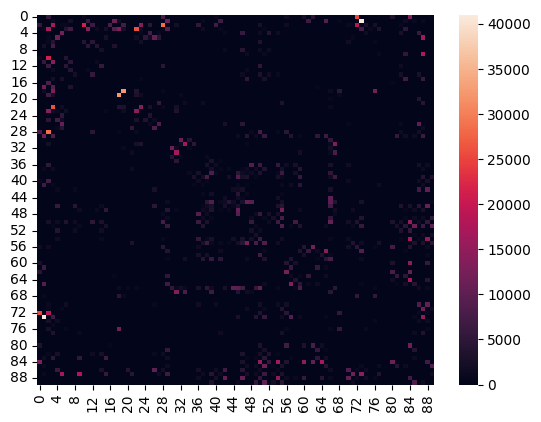

In [9]:
import seaborn as sns

sns.heatmap(weighted_connectivity[:,:,0])

In [10]:
print("Original shape:", weighted_connectivity.shape)

# (90, 90, 446) → (446, 90, 90)
all_networks_np = np.transpose(weighted_connectivity, (2, 0, 1))
print("After transpose:", all_networks_np.shape)   # (446, 90, 90)

# 0 stays 0, anything > 0 becomes 1
all_binary_networks_np = (all_networks_np > 0).astype(np.float32)

print("Binary shape:", all_binary_networks_np.shape)  # (446, 90, 90)

all_binary_networks = torch.tensor(all_binary_networks_np, device=DEVICE)

S, N, _ = all_binary_networks.shape
print("Num subjects:", S)  #  446
print("Num nodes:", N)     # 90


Original shape: (90, 90, 446)
After transpose: (446, 90, 90)
Binary shape: (446, 90, 90)
Num subjects: 446
Num nodes: 90


In [11]:
num_connections = int(all_binary_networks.sum().item() / 446 )
print(f"The binary consensus network contains {num_connections} connections.")

The binary consensus network contains 800 connections.


In [ ]:
num_simulations = 1 #when i run the seed, match the number of simulations -- do not redefine below
file_path = "/Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/seed.npy"
seed = np.load(file_path)
seed_new = np.broadcast_to(seed, (num_simulations,seed.shape[0], seed.shape[1]))
tensor_seed = torch.tensor(seed_new, device=DEVICE)

In [44]:
#print(seed_new)
#print(tensor_seed)

In [21]:
eta_values = torch.Tensor(torch.linspace(-5, 0, 2))
print(f'Eta Values: {eta_values}')
gamma_values = torch.Tensor(torch.linspace(0, 1, 2))
print(gamma_values)
print(f'Num connections: {num_connections}')

Eta Values: tensor([-5.,  0.])
tensor([0., 1.])
Num connections: 800


In [22]:
binary_sweep_parameters = fitting.BinarySweepParameters(
    eta = eta_values,
    gamma = gamma_values,
    lambdah = torch.Tensor([0.0]),
    distance_relationship_type = ["powerlaw"],
    preferential_relationship_type = ["powerlaw"],
    heterochronicity_relationship_type = ["powerlaw"],
    generative_rule = [generative_rules.MatchingIndex()],
    num_iterations = [num_connections],
)

#seed set
sweep_config = fitting.SweepConfig(
    binary_sweep_parameters = binary_sweep_parameters,
    # weighted_sweep_parameters = weighted_sweep_parameters,
    num_simulations = num_simulations,
    distance_matrix = [distance_matrix], 
    seed_weight_matrix = tensor_seed   
)


In [ ]:
from gnm.fitting.experiment_saving import ExperimentEvaluation
from gnm import evaluation

criteria = [ evaluation.ClusteringKS(), evaluation.DegreeKS(), evaluation.EdgeLengthKS(distance_matrix), evaluation.BetweennessKS() ]
energy = evaluation.MaxCriteria( criteria )
binary_evaluations = [energy]

# Run the full sweep
experiments = fitting.perform_sweep(sweep_config=sweep_config, 
                                binary_evaluations=binary_evaluations, 
                                real_binary_matrices= all_binary_networks,
                                # weighted_evaluations=weighted_evaluations,
                                save_model = False,
                                save_run_history = False,
                                verbose=True
)


Using device: cpu for GNM simulations


Configuration Iterations:  18%|█▊        | 7/40 [01:16<05:51, 10.64s/it]

In [ ]:
eval = ExperimentEvaluation('./test_experiment_evals_50_eta_gamma')
eval.save_experiments(experiments)
eval.get_dataframe_of_results() 

Total entries for connectome_index: 45
Total entries for eta: 45
Total entries for gamma: 45
Total entries for mean_of_max_ks_per_connectome: 45
Compiled results for 1 unique connectomes.


/Users/anchalbhaskar/Documents/Projects/GenerativeNetworkModels/src/gnm/fitting/experiment_saving.py:403: UserWarning: Assumes default Max KS Distance metric was used during evaluation.
  warn("Assumes default Max KS Distance metric was used during evaluation.")


,connectome_index,eta,gamma,mean_of_max_ks_per_connectome
0,0,-5.0,0.0,0.609342
1,0,-5.0,0.0,0.609342
2,0,-5.0,1.0,0.810488
3,0,-5.0,0.0,0.609342
4,0,-5.0,1.0,0.810488
5,0,-5.0,2.0,0.732436
6,0,-5.0,0.0,0.609342
7,0,-5.0,1.0,0.810488
8,0,-5.0,2.0,0.732436
9,0,-2.0,0.0,0.677105


In [ ]:
eval.list_experiment_parameters()

Experiment Parameters:
   - eta
   - gamma
   - lambdah
   - distance_relationship_type
   - preferential_relationship_type
   - heterochronicity_relationship_type
   - generative_rule
   - num_iterations
   - prob_offset
   - binary_updates_per_iteration
   - n_participants
   - mean_of_max_ks_per_connectome
   - std_of_max_ks_per_connectome
   - per_connectome_binary_evals


dict_keys(['eta', 'gamma', 'lambdah', 'distance_relationship_type', 'preferential_relationship_type', 'heterochronicity_relationship_type', 'generative_rule', 'num_iterations', 'prob_offset', 'binary_updates_per_iteration', 'n_participants', 'mean_of_max_ks_per_connectome', 'std_of_max_ks_per_connectome', 'per_connectome_binary_evals'])

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# every combination of eta and gamma, for 10 connectomes
eta_values = np.linspace(-3, 3, 10)
gamma_values = np.linspace(-3, 3, 10)

# generate a synthetic ks results dataframe
results_df = pd.DataFrame({
    'connectome_index': np.tile(np.arange(10), 100),
    'eta': np.repeat(eta_values, 100),
    'gamma': np.tile(gamma_values, 100),
    'mean_ks': np.random.uniform(0, 1, 1000),
    'std_ks': np.random.uniform(0, 1, 1000)
})

plt.figure(figsize=(8,6))

# scatter eta and gamma points, coloured by energy
etas = results_df['eta'].unique()
gammas = results_df['gamma'].unique()

avg_energies = results_df.groupby(['eta', 'gamma'])['mean_ks'].mean().unstack()

sns.heatmap(avg_energies, xticklabels=np.round(gammas, 2), yticklabels=np.round(etas, 2), cmap='Reds', cbar=True)
plt.title('Average KS Energy across Eta and Gamma Values')
plt.xlabel('Gamma')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.ylabel('Eta')
plt.show()

NameError: name 'pd' is not defined